In [1]:
import h5py
from matplotlib import pyplot as plt

In [12]:
f_FCT = h5py.File('re_vgm_sand_10m_1d.h5', 'r')

elements = f_FCT['elementsSpatial_Domain0'][:]
nodes = f_FCT['nodesSpatial_Domain0'][:]
psi = f_FCT['pressure_head_t0'][:]


In [19]:
f = h5py.File('Galerkin/re_vgm_sand_10m_1d.h5', 'r')

elements_G = f['elementsSpatial_Domain0'][:]
nodes_G = f['nodesSpatial_Domain0'][:]
psi_G = f['pressure_head_t0'][:]


In [13]:
import xml.etree.ElementTree as ET
root= ET.fromstring(f['Mesh_Spatial_Domain_500'][:])
root.findall('Time')[0].attrib

{'Value': '2.083333e-02', 'Name': '500'}

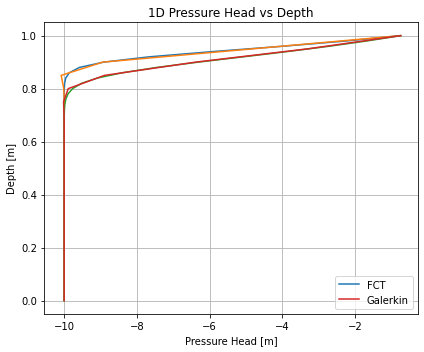

In [30]:
import matplotlib.pyplot as plt

# Pressure head from both FCT and Galerkin solutions
psi5_FCT = f_FCT['pressure_head_t{0}'.format(20)][:]   
psi10_FCT = f_FCT['pressure_head_t{0}'.format(50)][:]  

psi5_G = f['pressure_head_t{0}'.format(20)][:]         
psi10_G = f['pressure_head_t{0}'.format(50)][:]

# Depth coordinates
z_FCT = nodes[:, 0]
z_G = nodes_G[:, 0]


plt.figure(figsize=(6, 5))

plt.plot(psi5_FCT, z_FCT, label='FCT')
plt.plot(psi5_G,z_G,     label=None)

plt.plot(psi10_FCT, z_FCT, label=None)
plt.plot(psi10_G[idx_G],     z_G[idx_G],     label='Galerkin')

plt.xlabel('Pressure Head [m]')
plt.ylabel('Depth [m]')
#plt.gca().invert_yaxis()  # Top of column at top of plot
plt.title('1D Pressure Head vs Depth')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('1d_pressure_profiles.png')
plt.show()
